In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.sparse import issparse

import sys, os

from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


In [2]:
import os, sys


In [3]:
intermediate_directory = str(ANALYSIS_DIR)


In [4]:
clustered_EECs = sc.read_h5ad(f'{intermediate_directory}/subclustered_EECs_egfDuod_D10_Lapa_DZ.h5ad')

In [5]:
clustered_EECs

AnnData object with n_obs × n_vars = 1397 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'leiden_subcluster'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'X_name', 'dendrogram_leiden_subcluster', 'hvg', 'leiden_colors', 'leiden_subcluster', 'leiden_subcluster_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [6]:
# Make sure leiden is string
clustered_EECs.obs["leiden_subcluster"] = clustered_EECs.obs["leiden_subcluster"].astype(str)

# Base label for everything
clustered_EECs.obs["manual_label"] = "Unlabelled_EECs"

# Peptide hormones: cluster 

peptide_eec_mask = (clustered_EECs.obs["leiden_subcluster"] == "4") | (clustered_EECs.obs["leiden_subcluster"] == "5")
clustered_EECs.obs.loc[peptide_eec_mask, "manual_label"] = "Peptide EECs"

enterochromaffin_mask = (clustered_EECs.obs["leiden_subcluster"] == "1")
clustered_EECs.obs.loc[enterochromaffin_mask, "manual_label"] = "Enterochromaffin EECs"


In [7]:
print(clustered_EECs.obs["manual_label"].value_counts())

manual_label
Unlabelled_EECs          868
Enterochromaffin EECs    267
Peptide EECs             262
Name: count, dtype: int64


In [8]:
def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

In [9]:


m_cell_pos = gene_expr_bool(clustered_EECs, "MLN")
mask_m_cell = m_cell_pos
clustered_EECs.obs.loc[mask_m_cell, "manual_label"] = "Peptide EECs"

x_cell_pos = gene_expr_bool(clustered_EECs, "GHRL")
mask_x_cell = m_cell_pos
clustered_EECs.obs.loc[mask_x_cell, "manual_label"] = "Peptide EECs"

g_cell_pos = gene_expr_bool(clustered_EECs, "GAST")
mask_g_cell = g_cell_pos
clustered_EECs.obs.loc[mask_g_cell, "manual_label"] = "Peptide EECs"

k_cell_pos = gene_expr_bool(clustered_EECs, "GIP")
mask_k_cell = k_cell_pos
clustered_EECs.obs.loc[mask_k_cell, "manual_label"] = "Peptide EECs"

i_cell_pos = gene_expr_bool(clustered_EECs, "CCK")
mask_i_cell = m_cell_pos
clustered_EECs.obs.loc[mask_i_cell, "manual_label"] = "Peptide EECs"


# Sanity check
print(clustered_EECs.obs["manual_label"].value_counts())

manual_label
Unlabelled_EECs          854
Peptide EECs             276
Enterochromaffin EECs    267
Name: count, dtype: int64


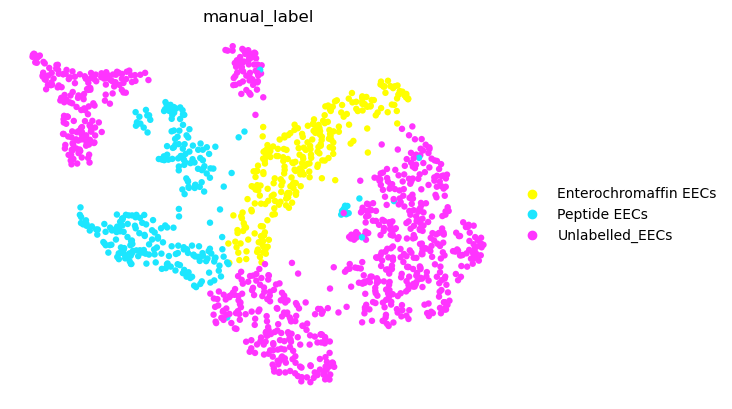

In [10]:
sc.pl.umap(
    clustered_EECs,
    color="manual_label",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    frameon=False
)

In [11]:
## Save our clustered data

intermediate_directory = str(ANALYSIS_DIR)
sc.write(f'{intermediate_directory}/labelled_subclustered_EECs_egfDuod_D10_Lapa_DZ.h5ad', clustered_EECs)